# AirShift — Labeling

This notebook applies the deterioration event definition established in the previous stage to create the target label for machine learning.

The labeling process focuses on:

* Applying the selected PM2.5 deterioration threshold
* Using the selected future prediction horizon
* Creating a binary target variable
* Handling observations with insufficient information for labeling
* Validating the resulting class distribution
* Saving the labeled dataset for model development

The target label represents whether a future air quality deterioration event occurs according to the predefined event definition.

No model training is performed in this notebook.


## 1. Load the Feature-Engineered Dataset

The feature-engineered dataset created in the previous stage is loaded as the starting point for the labeling process.

The dataset contains the temporal and historical air quality features required to define the deterioration target.

The original feature-engineered dataset is not modified or overwritten.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("../data/processed")
OUTPUT_DIR = Path("../data/processed")

feature_file = DATA_DIR / "airshift_feature_engineered.csv"

df = pd.read_csv(
    feature_file,
    parse_dates=["datetime"]
)

print("Dataset shape:", df.shape)
print("Number of stations:", df["station"].nunique())
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())

Dataset shape: (420768, 99)
Number of stations: 12
Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00


## 2. Define the Labeling Configuration

The labeling configuration is defined according to the deterioration event definition established in the previous notebook.

The target is based on PM2.5, with a **30% deterioration threshold** and a **6-hour future horizon**.

These parameters will be used to create the binary target label in the following steps.


In [3]:
TARGET_POLLUTANT = "PM2.5"
FINAL_THRESHOLD = 0.30
FINAL_HORIZON_HOURS = 6

print("Labeling configuration:")
print(f"Target pollutant: {TARGET_POLLUTANT}")
print(f"Deterioration threshold: {FINAL_THRESHOLD * 100:.0f}%")
print(f"Future horizon: {FINAL_HORIZON_HOURS} hours")

Labeling configuration:
Target pollutant: PM2.5
Deterioration threshold: 30%
Future horizon: 6 hours


In [4]:
# Sort the dataset by monitoring station and datetime to preserve the
# chronological order required for accurate time-based labeling.
df = df.sort_values(
    ["station", "datetime"]
).reset_index(drop=True)

print("Data sorted successfully.")

Data sorted successfully.


## 3. Check PM2.5 Availability

Before creating the target label, the availability of the current PM2.5 values is checked.

A valid current PM2.5 value is required to calculate the relative change and determine whether a deterioration event occurs.

This step only evaluates missing values and does not remove or modify any observations.


In [5]:
# Check the number and percentage of missing current PM2.5 values.
pm25_missing = df["PM2.5"].isna().sum()

pm25_missing_percentage = (
    pm25_missing / len(df)
) * 100

print("Missing current PM2.5 values:", pm25_missing)
print(f"Missing percentage: {pm25_missing_percentage:.2f}%")

Missing current PM2.5 values: 1877
Missing percentage: 0.45%


### PM2.5 Availability Findings

The dataset contains **1,877 missing current PM2.5 values**, representing **0.45%** of all observations.

These observations will not be assigned a deterioration label because a valid current PM2.5 value is required to calculate the relative change.

The observations will be handled during the labeling process without creating artificial target values.


## 4. Calculate Future PM2.5 Values

To identify whether air quality deteriorates within the next 6 hours, the future PM2.5 concentration is examined across the six hourly observations following each prediction time.

For each observation, the maximum PM2.5 value within the next 6 hours is calculated separately for each monitoring station.

This approach matches the AirShift objective of detecting deterioration that may occur at any point during the future warning horizon rather than only at exactly 6 hours later.


In [6]:
# Calculate the maximum PM2.5 concentration observed during the
# following 6 hours for each monitoring station.

future_pm25_values = []

for hour in range(1, FINAL_HORIZON_HOURS + 1):
    future_pm25_values.append(
        df.groupby("station")[TARGET_POLLUTANT].shift(-hour)
    )

df["PM2.5_future_max_6h"] = pd.concat(
    future_pm25_values,
    axis=1
).max(axis=1)

print("Future maximum PM2.5 values calculated successfully.")

df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_future_max_6h"
    ]
].head(10)

Future maximum PM2.5 values calculated successfully.


,station,datetime,PM2.5,PM2.5_future_max_6h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,8.0
1,Aotizhongxin,2013-03-01 01:00:00,8.0,7.0
2,Aotizhongxin,2013-03-01 02:00:00,7.0,6.0
3,Aotizhongxin,2013-03-01 03:00:00,6.0,5.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,5.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,3.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,6.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,8.0


### Future PM2.5 Findings

The maximum PM2.5 concentration within the following 6 hours was calculated separately for each monitoring station.

Using the maximum future value ensures that deterioration occurring at any point within the 6-hour prediction horizon can be captured.

These future values will be compared with the current PM2.5 concentration in the next step to calculate the relative deterioration.


## 5. Calculate Future PM2.5 Change

The relative change in PM2.5 is calculated by comparing the current PM2.5 concentration with the maximum concentration observed during the following 6 hours.

A positive value indicates that PM2.5 increased during the future horizon, while a negative value indicates that the future maximum remained below the current concentration.

The relative change will be used in the next step to determine whether the predefined 30% deterioration threshold is reached.


In [7]:
df["PM2.5_future_change_6h"] = np.where(
    df[TARGET_POLLUTANT] > 0,
    (
        df["PM2.5_future_max_6h"] - df[TARGET_POLLUTANT]
    ) / df[TARGET_POLLUTANT],
    np.nan
)

print("Future PM2.5 change calculated successfully.")

df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_future_max_6h",
        "PM2.5_future_change_6h"
    ]
].head(10)

Future PM2.5 change calculated successfully.


,station,datetime,PM2.5,PM2.5_future_max_6h,PM2.5_future_change_6h
0,Aotizhongxin,2013-03-01 00:00:00,4.0,8.0,1.000000
1,Aotizhongxin,2013-03-01 01:00:00,8.0,7.0,-0.125000
2,Aotizhongxin,2013-03-01 02:00:00,7.0,6.0,-0.142857
3,Aotizhongxin,2013-03-01 03:00:00,6.0,5.0,-0.166667
4,Aotizhongxin,2013-03-01 04:00:00,3.0,5.0,0.666667
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0,-0.400000
6,Aotizhongxin,2013-03-01 06:00:00,3.0,3.0,0.000000
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0,0.000000
8,Aotizhongxin,2013-03-01 08:00:00,3.0,6.0,1.000000
9,Aotizhongxin,2013-03-01 09:00:00,3.0,8.0,1.666667


### Future PM2.5 Change Findings

The relative change in PM2.5 was calculated by comparing the current concentration with the maximum concentration observed during the following 6 hours.

Positive values indicate an increase in PM2.5 during the future horizon, while negative values indicate that the future maximum remained below the current concentration.

For example, an increase from 3.0 to 6.0 results in a relative change of **1.0**, corresponding to a **100% increase**.

The resulting relative change will be used to determine whether the **30% deterioration threshold** is reached when creating the target label.


## 6. Create the Deterioration Label

The deterioration target is created using the predefined **30% PM2.5 increase threshold** over the following **6 hours**.

An observation is labeled as a deterioration event (`1`) when the maximum PM2.5 concentration during the next 6 hours is at least **30% higher** than the current PM2.5 concentration.

Observations without sufficient PM2.5 information are not assigned a negative label. Instead, their target remains missing because the occurrence of a deterioration event cannot be reliably determined.


In [8]:
df["Deterioration"] = np.where(
    df["PM2.5_future_change_6h"].notna(),
    (df["PM2.5_future_change_6h"] >= FINAL_THRESHOLD).astype(int),
    np.nan
)

print("Deterioration labels created successfully.")

df[
    [
        "station",
        "datetime",
        "PM2.5",
        "PM2.5_future_max_6h",
        "PM2.5_future_change_6h",
        "Deterioration"
    ]
].head(10)

Deterioration labels created successfully.


,station,datetime,PM2.5,PM2.5_future_max_6h,PM2.5_future_change_6h,Deterioration
0,Aotizhongxin,2013-03-01 00:00:00,4.0,8.0,1.000000,1.0
1,Aotizhongxin,2013-03-01 01:00:00,8.0,7.0,-0.125000,0.0
2,Aotizhongxin,2013-03-01 02:00:00,7.0,6.0,-0.142857,0.0
3,Aotizhongxin,2013-03-01 03:00:00,6.0,5.0,-0.166667,0.0
4,Aotizhongxin,2013-03-01 04:00:00,3.0,5.0,0.666667,1.0
5,Aotizhongxin,2013-03-01 05:00:00,5.0,3.0,-0.400000,0.0
6,Aotizhongxin,2013-03-01 06:00:00,3.0,3.0,0.000000,0.0
7,Aotizhongxin,2013-03-01 07:00:00,3.0,3.0,0.000000,0.0
8,Aotizhongxin,2013-03-01 08:00:00,3.0,6.0,1.000000,1.0
9,Aotizhongxin,2013-03-01 09:00:00,3.0,8.0,1.666667,1.0


## 7. Validate the Target Distribution

The distribution of the newly created deterioration target is examined to verify the number of deterioration and non-deterioration observations.

Missing target values are also checked because observations without sufficient PM2.5 information cannot be reliably classified.

This validation helps assess whether the resulting target is suitable for machine learning.


In [9]:
target_counts = df["Deterioration"].value_counts(dropna=False)

target_percentages = (
    df["Deterioration"]
    .value_counts(normalize=True, dropna=False)
    * 100
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

target_summary

,count,percentage
Deterioration,,
0.0,220397,52.379696
1.0,198440,47.161381
NaN,1931,0.458923


### Target Distribution Findings

The target labeling resulted in **220,397 non-deterioration observations (52.38%)** and **198,440 deterioration observations (47.16%)**.

The resulting classes are relatively balanced, with deterioration events representing approximately **47%** of the valid observations.

A small proportion of observations (**0.46%**) have missing target values because sufficient PM2.5 information was not available to determine whether deterioration occurred.

These observations will not be assigned an artificial target value and will be excluded from model training in the model development stage.


### Figure 7 — Deterioration Target Distribution

The figure shows the distribution of the valid deterioration target labels.

The relatively balanced distribution between deterioration and non-deterioration observations indicates that the target does not have a severe class imbalance.


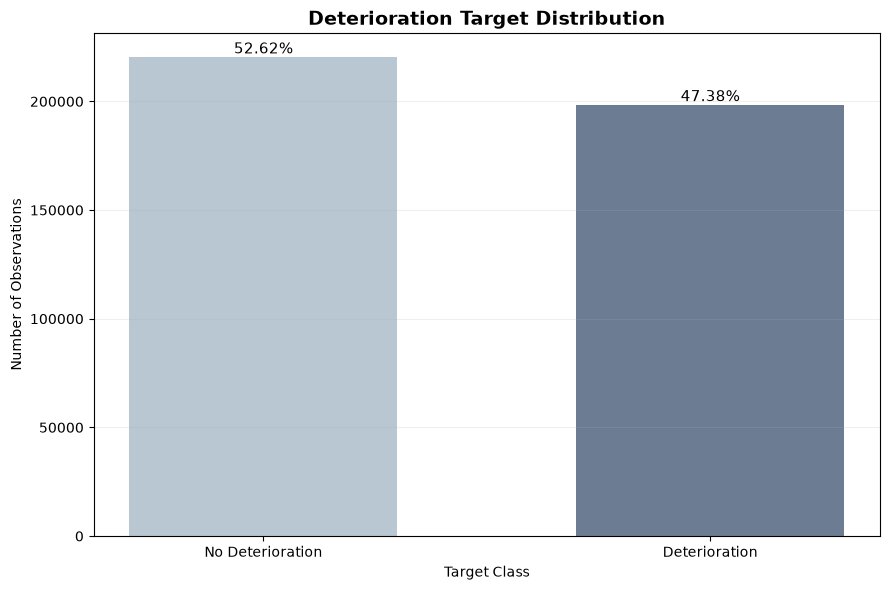

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\05_labeling\figure_07_deterioration_target_distribution.png


In [10]:


# Create the folder for Labeling figures if it does not already exist.
FIGURES_DIR = Path("../reports/figures/05_labeling")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Count valid target labels and exclude missing target values.
label_counts = (
    df["Deterioration"]
    .dropna()
    .value_counts()
    .sort_index()
)

labels = [
    "No Deterioration",
    "Deterioration"
]

values = [
    label_counts.get(0, 0),
    label_counts.get(1, 0)
]

# Calculate percentages for annotation.
total_valid = sum(values)

percentages = [
    (value / total_valid) * 100
    for value in values
]

# AirShift cool, calm, muted color palette.
colors = [
    "#B8C7D1",
    "#6B7C93"
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    labels,
    values,
    width=0.6,
    color=colors
)

plt.title(
    "Deterioration Target Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Target Class")
plt.ylabel("Number of Observations")

plt.grid(
    axis="y",
    alpha=0.2
)

# Add percentage labels above each bar.
for bar, percentage in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

# Save the figure.
figure_path = (
    FIGURES_DIR /
    "figure_07_deterioration_target_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

### Target Distribution Findings

The target distribution shows that **52.62%** of the valid observations are classified as non-deterioration, while **47.38%** are classified as deterioration.

The two classes are relatively balanced, indicating that the target does not suffer from a severe class imbalance.

This balanced distribution provides a suitable basis for training a binary classification model in the model development stage.


## 8. Validate Deterioration Distribution by Station

The distribution of deterioration events is examined across the monitoring stations.

This check helps determine whether deterioration events are reasonably distributed across the 12 stations or whether some stations have substantially different event frequencies.

Only observations with valid target labels are included in this analysis.


In [11]:
station_target_summary = (
    df.dropna(subset=["Deterioration"])
      .groupby("station")["Deterioration"]
      .agg(
          total_observations="count",
          deterioration_events="sum",
          deterioration_rate="mean"
      )
      .reset_index()
)

station_target_summary["deterioration_rate"] *= 100

station_target_summary = station_target_summary.sort_values(
    "deterioration_rate",
    ascending=False
)

station_target_summary

,station,total_observations,deterioration_events,deterioration_rate
1,Changping,34774,17017.0,48.935987
2,Dingling,34917,16907.0,48.420540
9,Tiantan,35053,16883.0,48.164208
7,Nongzhanguan,35020,16860.0,48.143918
8,Shunyi,34774,16665.0,47.923736
11,Wanshouxigong,35016,16718.0,47.743889
3,Dongsi,34894,16487.0,47.248811
0,Aotizhongxin,34655,16281.0,46.980234
4,Guanyuan,34922,16195.0,46.374778
10,Wanliu,35058,16232.0,46.300416


### Deterioration Distribution by Station Findings

The deterioration rate was examined across all 12 monitoring stations.

The deterioration rates range from **46.08% to 48.94%**, with a difference of approximately **2.86 percentage points** between the lowest and highest rates.

This relatively small variation indicates that deterioration events are distributed consistently across the monitoring stations, with no station showing a substantially different event frequency.


### Figure 8 — Deterioration Rate by Monitoring Station

The figure compares the percentage of deterioration events across the 12 monitoring stations.

The stations are ordered from the highest to the lowest deterioration rate to make differences between stations easier to compare.

The relatively similar rates across stations indicate that deterioration events are distributed consistently across the monitoring network.


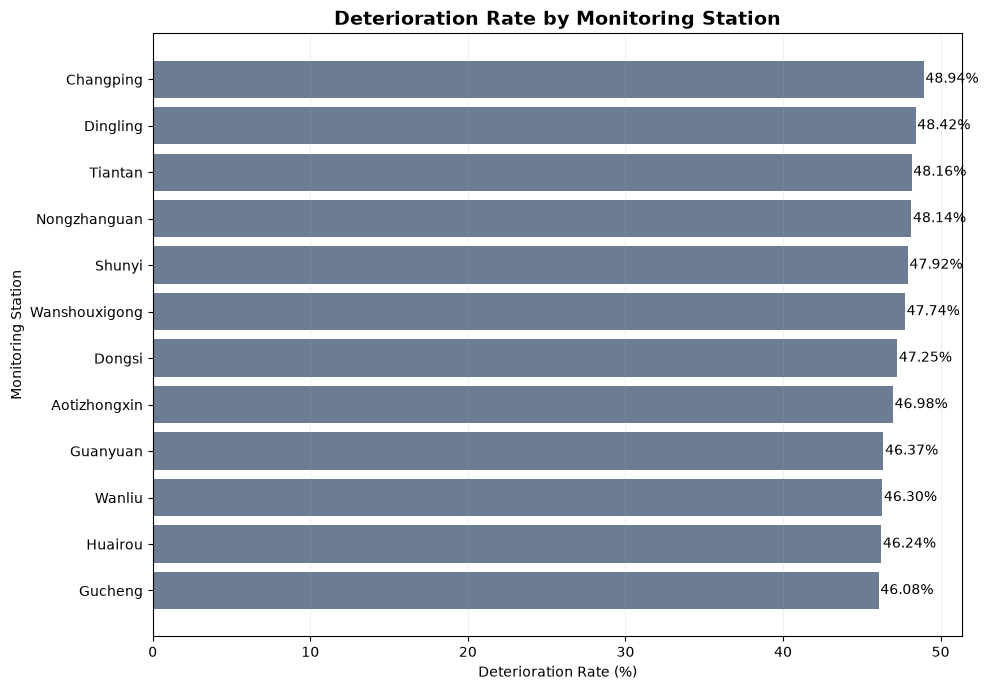

Figure saved successfully:
C:\Users\HP\Desktop\Projects\airshift\reports\figures\05_labeling\figure_08_deterioration_rate_by_station.png


In [12]:
# Create the folder for Labeling figures if it does not already exist.
FIGURES_DIR = Path("../reports/figures/05_labeling")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Sort stations by deterioration rate from highest to lowest.
plot_data = station_target_summary.sort_values(
    "deterioration_rate",
    ascending=False
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    plot_data["station"],
    plot_data["deterioration_rate"],
    color="#6B7C93"
)

# Reverse the y-axis so the highest rate appears at the top.
plt.gca().invert_yaxis()

plt.title(
    "Deterioration Rate by Monitoring Station",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Deterioration Rate (%)")
plt.ylabel("Monitoring Station")

plt.grid(
    axis="x",
    alpha=0.2
)

# Add percentage labels to the bars.
for bar, value in zip(
    bars,
    plot_data["deterioration_rate"]
):
    plt.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        fontsize=10
    )

plt.tight_layout()

# Save the figure.
figure_path = (
    FIGURES_DIR /
    "figure_08_deterioration_rate_by_station.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(figure_path.resolve())

## 9. Validate Missing Target Labels

Before preparing the final labeled dataset, the missing deterioration labels are investigated.

A missing target can occur when the current PM2.5 value is unavailable or when the future PM2.5 values required to determine deterioration are unavailable.

This validation helps ensure that observations are excluded from model training only when the deterioration event cannot be determined reliably.


In [13]:
# Check the main reasons why the deterioration target is missing.

missing_target = df["Deterioration"].isna()

current_pm25_missing = df[TARGET_POLLUTANT].isna()

future_pm25_missing = df["PM2.5_future_max_6h"].isna()

missing_target_summary = pd.DataFrame({
    "condition": [
        "Missing current PM2.5",
        "Missing future PM2.5 maximum",
        "Missing deterioration target"
    ],
    "count": [
        current_pm25_missing.sum(),
        future_pm25_missing.sum(),
        missing_target.sum()
    ]
})

missing_target_summary["percentage_of_dataset"] = (
    missing_target_summary["count"] / len(df) * 100
)

missing_target_summary

,condition,count,percentage_of_dataset
0,Missing current PM2.5,1877,0.446089
1,Missing future PM2.5 maximum,1601,0.380495
2,Missing deterioration target,1931,0.458923


In [14]:
# Check whether all six future PM2.5 observations are available.
# This is important because the deterioration event is defined
# using the maximum PM2.5 value across the complete 6-hour horizon.

future_pm25_columns = []

for hour in range(1, FINAL_HORIZON_HOURS + 1):
    column_name = f"_future_pm25_{hour}h"
    
    df[column_name] = (
        df.groupby("station")[TARGET_POLLUTANT]
          .shift(-hour)
    )
    
    future_pm25_columns.append(column_name)

future_missing_count = (
    df[future_pm25_columns]
    .isna()
    .sum(axis=1)
)

future_window_summary = pd.Series({
    "Complete 6-hour future window": (future_missing_count == 0).sum(),
    "At least one missing future hour": (future_missing_count > 0).sum(),
    "All six future hours missing": (future_missing_count == 6).sum()
})

future_window_summary

C:\Users\HP\AppData\Local\Temp\ipykernel_4872\2063373855.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[column_name] = (


Complete 6-hour future window       418454
At least one missing future hour      2314
All six future hours missing          1601
dtype: int64

In [15]:
# Identify observations where the complete 6-hour future window
# is not available.

incomplete_future_window = future_missing_count > 0

current_pm25_missing = df[TARGET_POLLUTANT].isna()

# Count observations affected by either missing current PM2.5
# or an incomplete future 6-hour window.
affected_by_missing_data = (
    current_pm25_missing | incomplete_future_window
)

print(
    "Observations with missing current PM2.5:",
    current_pm25_missing.sum()
)

print(
    "Observations with incomplete future 6-hour window:",
    incomplete_future_window.sum()
)

print(
    "Observations affected by missing information:",
    affected_by_missing_data.sum()
)

print(
    "Percentage of dataset affected:",
    f"{affected_by_missing_data.mean() * 100:.2f}%"
)

Observations with missing current PM2.5: 1877
Observations with incomplete future 6-hour window: 2314
Observations affected by missing information: 2387
Percentage of dataset affected: 0.57%


## 10. Recalculate the Label Using Complete Windows

The future PM2.5 values are recalculated using a complete 6-hour future window to ensure that deterioration events are determined reliably.

An observation is considered valid for labeling only when PM2.5 is available for all six hours following the current observation.

If any of the six future observations is missing, the future maximum and deterioration label remain missing.

This approach prevents partial future windows from being used to create potentially unreliable target labels and ensures that the deterioration definition is applied consistently across observations.


In [16]:
# Calculate the future PM2.5 values for each of the next six hours.
# A complete future window is required for reliable target labeling.

future_pm25_values = []

for hour in range(1, FINAL_HORIZON_HOURS + 1):
    future_pm25_values.append(
        df.groupby("station")[TARGET_POLLUTANT].shift(-hour)
    )

future_pm25 = pd.concat(
    future_pm25_values,
    axis=1
)

# Calculate the maximum PM2.5 only when all six future values are available.
# If any future hour is missing, the future maximum remains NaN.

df["PM2.5_future_max_6h"] = future_pm25.max(
    axis=1,
    skipna=False
)

print("Future PM2.5 maximum recalculated using complete 6-hour windows.")

Future PM2.5 maximum recalculated using complete 6-hour windows.


In [17]:
# Remove temporary future-value columns created during validation.

df = df.drop(
    columns=future_pm25_columns
)

print("Temporary future-value columns removed.")

Temporary future-value columns removed.


In [18]:
# Recalculate the relative PM2.5 change using the validated
# complete 6-hour future window.

df["PM2.5_future_change_6h"] = np.where(
    df[TARGET_POLLUTANT] > 0,
    (
        df["PM2.5_future_max_6h"] - df[TARGET_POLLUTANT]
    ) / df[TARGET_POLLUTANT],
    np.nan
)

In [19]:
# Recreate the deterioration target using the validated future window.

df["Deterioration"] = np.where(
    df["PM2.5_future_change_6h"].notna(),
    (df["PM2.5_future_change_6h"] >= FINAL_THRESHOLD).astype(int),
    np.nan
)

print("Deterioration labels recreated successfully.")

Deterioration labels recreated successfully.


### Complete Future Window Findings

The deterioration labels were recalculated using only observations with a complete 6-hour future PM2.5 window.

After applying this requirement, **2,387 observations**, representing **0.57%** of the dataset, could not be assigned a reliable deterioration label.

The remaining observations have sufficient information to determine whether a PM2.5 deterioration event occurred within the following 6 hours.

This approach ensures that the target labels are based on complete future information and avoids assigning labels from partially observed prediction windows.
